# CPU CFT Extraction Summary

This notebook analyzes one completed CPU CFT extraction campaign produced by `run_cpu_cft_sweep.py`. The campaign contains Born trajectory weights, tangent-cocycle one-body Lyapunov spectra, and Choi-covariance finite-sector rapidities for the domain-wall monitored free-fermion circuit.

The leading trajectory free-energy density is estimated from sampled Born probabilities,

$$
Y_s(L,t)=-\log p_{\xi_s(0:t)},\qquad
f_0(L,t)=\frac{1}{\alpha L t}\,\overline{Y_s(L,t)} .
$$

For a multi-circumference campaign, the effective central charge is extracted from the cylinder finite-size form

$$
f_0(L)=f_\infty-\frac{\pi c_{\rm eff}}{6L^2}+O(L^{-4}).
$$

The excited-sector estimates are not computed from additional Born probabilities. They are inferred from transfer spectra. One-body tangent or Choi gaps are lifted to candidate Fock-space gaps by

$$
\Delta_r(L,t)=\epsilon_1+\cdots+\epsilon_r,
\qquad
x_r(L,t)=\frac{L\Delta_r(L,t)}{2\pi\alpha} .
$$

The tangent and Choi routes are reported separately because they are different transfer objects. Choi endpoint/null sectors are bookkeeping data and are excluded from finite rapidity gaps.


## Runtime Setup

Set `CPU_RANGE` if you want the notebook process itself pinned to specific CPU cores. This does not rerun the simulations; it only affects notebook-side analysis and plotting.


In [1]:
# CPU allocation: set CPU_RANGE to e.g. "0-7" before running this cell.
import os
CPU_RANGE = ""
def _parse_cpu_range(spec):
    cpus = []
    for part in str(spec).split(','):
        part = part.strip()
        if not part:
            continue
        if '-' in part:
            lo, hi = part.split('-', 1)
            cpus.extend(range(int(lo), int(hi) + 1))
        else:
            cpus.append(int(part))
    return cpus
if CPU_RANGE and hasattr(os, 'sched_setaffinity'):
    os.sched_setaffinity(0, _parse_cpu_range(CPU_RANGE))
os.environ.setdefault('OMP_NUM_THREADS', str(len(_parse_cpu_range(CPU_RANGE)) or 1))
os.environ.setdefault('OPENBLAS_NUM_THREADS', os.environ['OMP_NUM_THREADS'])
os.environ.setdefault('MKL_NUM_THREADS', os.environ['OMP_NUM_THREADS'])
print('affinity =', sorted(os.sched_getaffinity(0)) if hasattr(os, 'sched_getaffinity') else 'unavailable')


affinity = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]


## Load Campaign and Report Parameters

The notebook reads `manifest.json`, `scalars_by_size.csv`, and the spectrum files under each `N{Nx}x{Ny}` folder. If `CAMPAIGN_DIR` is set in the environment, that directory is used; otherwise the newest campaign under `cpu_cft_extraction/outputs` with a `scalars_by_size.csv` is loaded.


In [2]:
from pathlib import Path
import csv, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'cpu_cft_extraction':
    NOTEBOOK_DIR = Path('/home/abhuiyan/class_A_fermionic_adaptive_circuit/cpu_cft_extraction')
sys.path.insert(0, str(NOTEBOOK_DIR))
from cft_analysis import fit_campaign

CAMPAIGN_DIR = os.environ.get('CAMPAIGN_DIR') or None
outputs = NOTEBOOK_DIR / 'outputs'

def _campaign_score(path):
    path = Path(path)
    try:
        with open(path / 'manifest.json', 'r', encoding='utf-8') as fh:
            man = json.load(fh)
    except Exception:
        man = {}
    try:
        with open(path / 'scalars_by_size.csv', 'r', encoding='utf-8') as fh:
            rows = list(csv.DictReader(fh))
    except Exception:
        rows = []
    Ls = []
    for row in rows:
        try:
            Ls.append(float(row.get('L', row.get('Ny', 'nan'))))
        except Exception:
            pass
    is_smoke = str(man.get('mode', '')).lower() == 'smoke'
    n_sizes = len(rows)
    max_L = max(Ls) if Ls else -1.0
    nx = float(man.get('Nx', -1) or -1)
    mtime = (path / 'scalars_by_size.csv').stat().st_mtime
    # Prefer non-smoke, multi-size, larger production-scale campaigns; use mtime only as a final tie-break.
    return (0 if is_smoke else 1, n_sizes, max_L, nx, mtime)

if CAMPAIGN_DIR is None:
    candidates = sorted({p.parent for p in outputs.rglob('scalars_by_size.csv')})
    if not candidates:
        raise FileNotFoundError('Run run_cpu_cft_sweep.py --smoke first, or set CAMPAIGN_DIR.')
    campaign = max(candidates, key=_campaign_score)
else:
    campaign = Path(CAMPAIGN_DIR).expanduser().resolve()
with open(campaign / 'manifest.json', 'r', encoding='utf-8') as fh:
    manifest = json.load(fh)
with open(campaign / 'scalars_by_size.csv', 'r', encoding='utf-8') as fh:
    scalars = list(csv.DictReader(fh))
print(campaign)
print(json.dumps(manifest, indent=2)[:1200])
key_plot_dir = campaign / 'key_plots'
key_plot_dir.mkdir(parents=True, exist_ok=True)


/home/abhuiyan/class_A_fermionic_adaptive_circuit/cpu_cft_extraction/outputs/tmux_L30L40_T5L_20260808_133322/production/20260808_133322_0188a5388e
{
  "Nx": 20,
  "Ny": [
    30,
    40
  ],
  "alpha": 1.0,
  "available_cpus_at_launch": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
   

In [3]:

from IPython.display import Markdown, display

rows = scalars
Ls = [int(float(r['L'])) for r in rows]
cycles = [int(float(r['cycles'])) for r in rows]
samples = [int(float(r['samples'])) for r in rows]
fit = fit_campaign(scalars, alpha=float(manifest['alpha']))

def _fmt(value, nd=5):
    try:
        value = float(value)
    except Exception:
        return str(value)
    if not np.isfinite(value):
        return 'not available'
    return f'{value:.{nd}g}'

lines = []
lines.append('## Campaign Summary')
lines.append('')
lines.append(f'- Campaign directory: `{campaign}`')
lines.append(f'- Canonical dynamics: `{manifest.get("canonical_dynamics_entry_point", "unknown")}`')
lines.append(f'- Geometry: `Nx={manifest.get("Nx")}`, `Ny={manifest.get("Ny")}`, interpreted as circumference `L=Ny`')
lines.append(f'- Cycles: `{cycles}`')
lines.append(f'- Samples per size: `{samples}`')
lines.append(f'- Aspect ratio convention: `alpha={manifest.get("alpha")}`')
lines.append(f'- Fock rank used in saved scalar summary: `r={manifest.get("fock_rank")}`')
lines.append(f'- Postselection: `{manifest.get("postselect")}`; forced-postselected trajectories are excluded from the `c_eff` interpretation')
lines.append(f'- Choi tracking: `{manifest.get("track_choi")}`')
lines.append('')
lines.append('### Fitted quantities')
lines.append('')
lines.append(f'- `c_eff`: `{_fmt(fit.get("ceff"))}`')
lines.append(f'- `x_tangent_fock`: `{_fmt(fit.get("x_tangent_fock"))}`')
lines.append(f'- `x_choi_fock`: `{_fmt(fit.get("x_choi_fock"))}`')
lines.append('')
if len(Ls) < 2:
    lines.append('Only one circumference is present, so finite-size fits for `c_eff` and thermodynamic `x` are intentionally unavailable.')
else:
    lines.append('The finite-size fits use the rows in `scalars_by_size.csv`; inspect the plots below before treating these as asymptotic values.')
lines.append('')
lines.append('### Size-resolved scalar table')
lines.append('')
lines.append('| L | cycles | samples | f0 | tangent x(L) | Choi x(L) | Choi endpoints | tangent nulls |')
lines.append('|---:|---:|---:|---:|---:|---:|---:|---:|')
for r in rows:
    lines.append(
        f'| {int(float(r["L"]))} | {int(float(r["cycles"]))} | {int(float(r["samples"]))} | '
        f'{_fmt(r["f0"])} | {_fmt(r["x_tangent_fock_size"])} | {_fmt(r["x_choi_fock_size"])} | '
        f'{_fmt(r["choi_endpoint_mean"])} | {_fmt(r["tangent_null_mean"])} |'
    )
display(Markdown('\n'.join(lines)))


## Campaign Summary

- Campaign directory: `/home/abhuiyan/class_A_fermionic_adaptive_circuit/cpu_cft_extraction/outputs/tmux_L30L40_T5L_20260808_133322/production/20260808_133322_0188a5388e`
- Canonical dynamics: `classA_U1FGTN.run_markov_circuit`
- Geometry: `Nx=20`, `Ny=[30, 40]`, interpreted as circumference `L=Ny`
- Cycles: `[150, 200]`
- Samples per size: `[10, 10]`
- Aspect ratio convention: `alpha=1.0`
- Fock rank used in saved scalar summary: `r=1`
- Postselection: `False`; forced-postselected trajectories are excluded from the `c_eff` interpretation
- Choi tracking: `True`

### Fitted quantities

- `c_eff`: `-256.94`
- `x_tangent_fock`: `0.15733`
- `x_choi_fock`: `0.17999`

The finite-size fits use the rows in `scalars_by_size.csv`; inspect the plots below before treating these as asymptotic values.

### Size-resolved scalar table

| L | cycles | samples | f0 | tangent x(L) | Choi x(L) | Choi endpoints | tangent nulls |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 30 | 150 | 10 | 3.3405 | 0.19958 | 0.19101 | 777.9 | 0 |
| 40 | 200 | 10 | 3.2751 | 0.23244 | 0.19959 | 1038 | 0 |

## Born Free-Energy Density Plateau

This is the time-convergence check for the leading trajectory free-energy density. It uses only `trajectory_weights.csv`, i.e. Born/correction log probabilities accumulated along physical trajectories. It is independent of whether tangent or Choi transfer observers were also enabled.


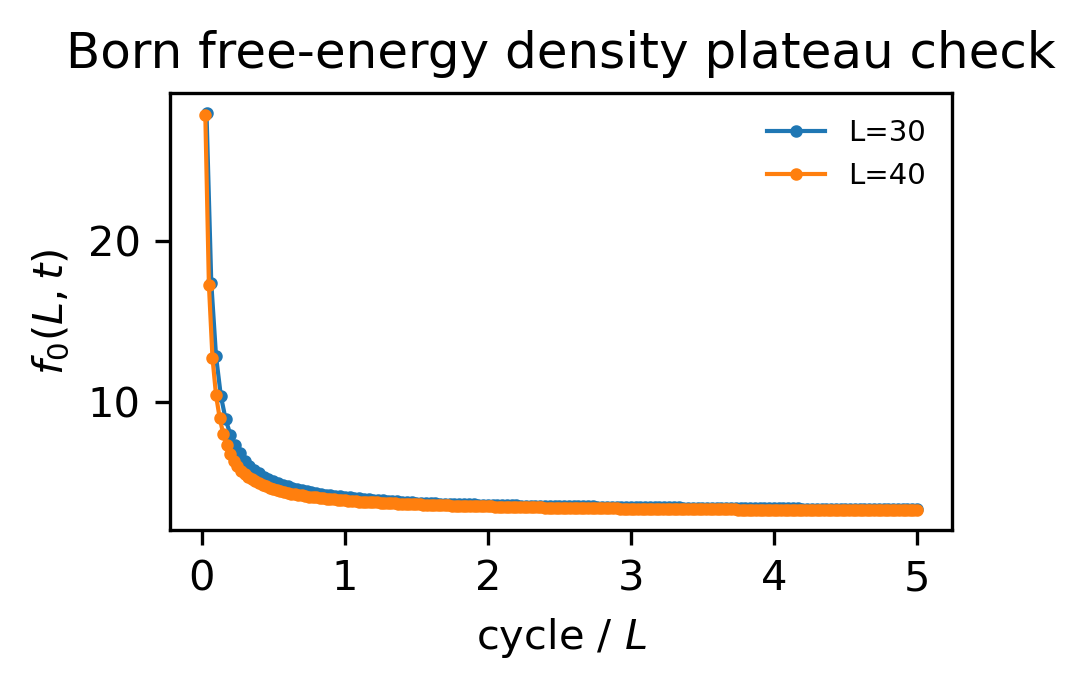

In [4]:

# Figure: Born free-energy density plateau check.
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
for row in scalars:
    L_i = int(float(row['L']))
    Nx_i = int(float(row['Nx']))
    Ny_i = int(float(row['Ny']))
    weights_path = campaign / f'N{Nx_i}x{Ny_i}' / 'trajectory_weights.csv'
    if not weights_path.exists():
        continue
    by_cycle = {}
    with open(weights_path, 'r', encoding='utf-8') as fh:
        for rec in csv.DictReader(fh):
            if int(float(rec.get('forced_postselect', 0))) != 0:
                continue
            cyc = int(float(rec['cycle']))
            by_cycle.setdefault(cyc, []).append(float(rec['minus_log_p']))
    cycles_plot = np.array(sorted(by_cycle), dtype=float)
    f0_t = np.array([np.mean(by_cycle[int(c)]) / (float(manifest['alpha']) * L_i * c) for c in cycles_plot])
    ax.plot(cycles_plot / L_i, f0_t, marker='o', ms=2, lw=1, label=f'L={L_i}')
ax.set_xlabel(r'cycle / $L$')
ax.set_ylabel(r'$f_0(L,t)$')
ax.set_title('Born free-energy density plateau check')
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(key_plot_dir / 'f0_plateau.png')
plt.show()


## Leading Free Energy and \(c_{\rm eff}\)

This plot fits the Born trajectory free-energy density versus `1/L^2`. The slope gives `c_eff = -6 m_0/pi`. This fit is meaningful only for campaigns with more than one circumference and after checking time convergence.


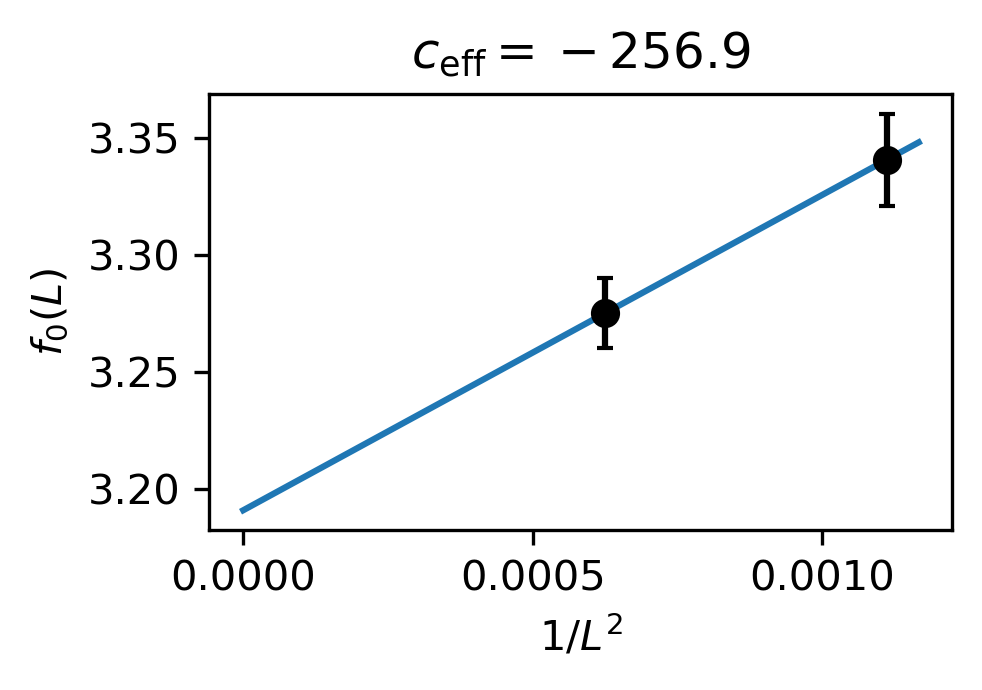

In [5]:
# Figure: f0 versus inverse circumference squared.
L = np.array([float(r['L']) for r in scalars])
f0 = np.array([float(r['f0']) for r in scalars])
f0_se = np.array([float(r['f0_se']) for r in scalars])
x = 1 / L**2
fit = fit_campaign(scalars, alpha=float(manifest['alpha']))
xx = np.linspace(0, x.max() * 1.05, 200)
yy = fit['ceff_fit']['intercept'] + fit['ceff_fit']['slope'] * xx
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.errorbar(x, f0, yerr=f0_se, fmt='o', color='black', capsize=2)
ax.plot(xx, yy, color='tab:blue')
ax.set_xlabel(r'$1/L^2$')
ax.set_ylabel(r'$f_0(L)$')
ax.set_title(rf'$c_{{\rm eff}}={fit["ceff"]:.4g}$')
fig.tight_layout()
fig.savefig(key_plot_dir / 'ceff_fit.png')
plt.show()


## One-Body and Fock-Lifted Transfer Gaps

This compares the raw one-body gaps and the saved rank-`r` Fock-lifted gaps from tangent and Choi transfer data. Equality is automatic only for `r=1`; for higher rank the Fock gap is an additive sum of the lowest finite one-body gaps.


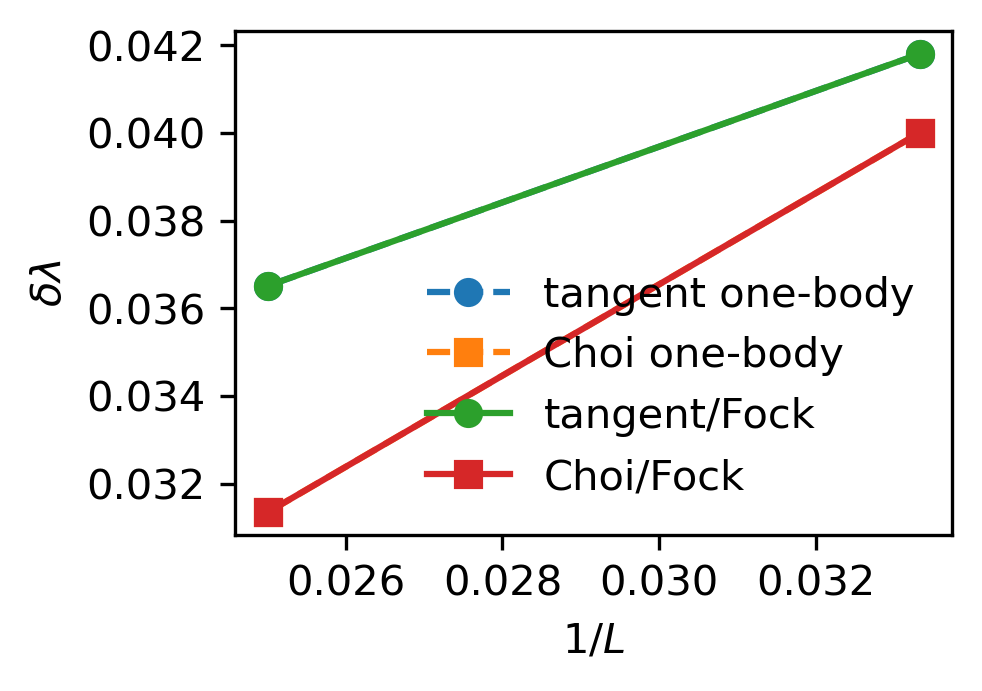

In [6]:
# Figure: one-body and additive Fock gaps versus inverse circumference.
tan_one = np.array([float(r['tangent_one_body_gap']) for r in scalars])
choi_one = np.array([float(r['choi_one_body_gap']) for r in scalars])
tan_gap = np.array([float(r['tangent_fock_gap']) for r in scalars])
choi_gap = np.array([float(r['choi_fock_gap']) for r in scalars])
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.plot(1/L, tan_one, 'o--', label=r'tangent one-body')
ax.plot(1/L, choi_one, 's--', label=r'Choi one-body')
ax.plot(1/L, tan_gap, 'o-', label=r'tangent/Fock')
ax.plot(1/L, choi_gap, 's-', label=r'Choi/Fock')
ax.set_xlabel(r'$1/L$')
ax.set_ylabel(r'$\delta\lambda$')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(key_plot_dir / 'xtyp_gap_fit.png')
plt.show()


## Size-Resolved Scaling-Dimension Estimates

For each size, the notebook reports `x_r(L)=L Delta_r/(2 pi alpha)`. The plotted trend versus `1/L` is a diagnostic for whether the finite-size values are approaching a stable thermodynamic scaling dimension.


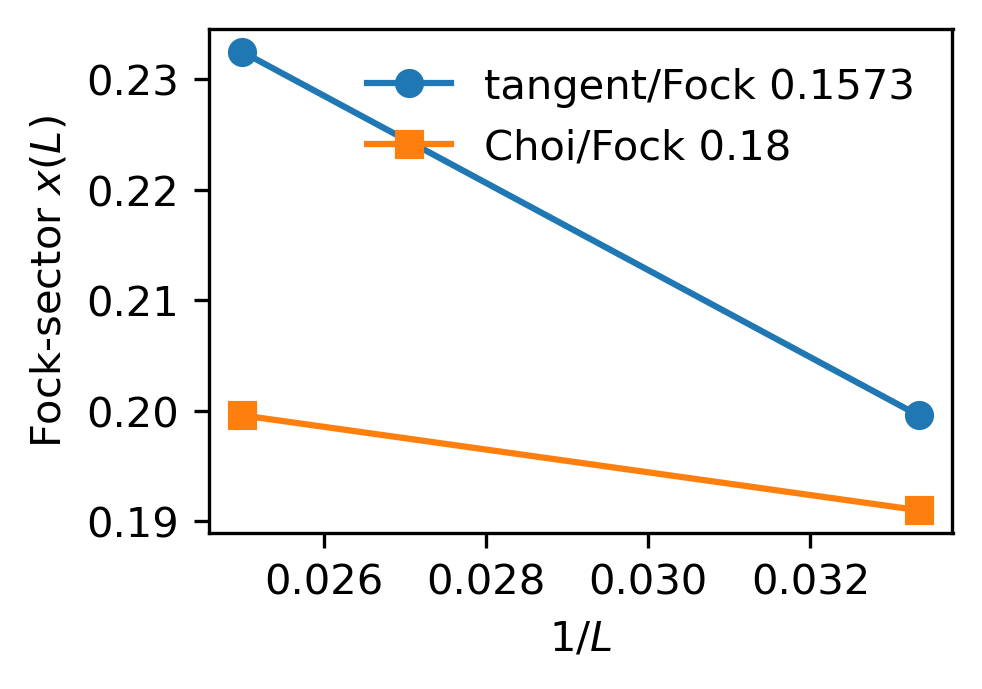

In [7]:
# Figure: size-resolved x estimates.
x_tan = np.array([float(r['x_tangent_fock_size']) for r in scalars])
x_choi = np.array([float(r['x_choi_fock_size']) for r in scalars])
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.plot(1/L, x_tan, 'o-', label=rf'tangent/Fock {fit["x_tangent_fock"]:.4g}')
ax.plot(1/L, x_choi, 's-', label=rf'Choi/Fock {fit["x_choi_fock"]:.4g}')
ax.set_xlabel(r'$1/L$')
ax.set_ylabel(r'Fock-sector $x(L)$')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(key_plot_dir / 'x_size_estimates.png')
plt.show()


## Combined Scaling and Endpoint Summary

This two-panel summary is kept for quick comparison with earlier `key_plots` outputs: the left panel shows size-resolved `x_r(L)` and fitted horizontal guides, while the right panel shows endpoint/null bookkeeping.


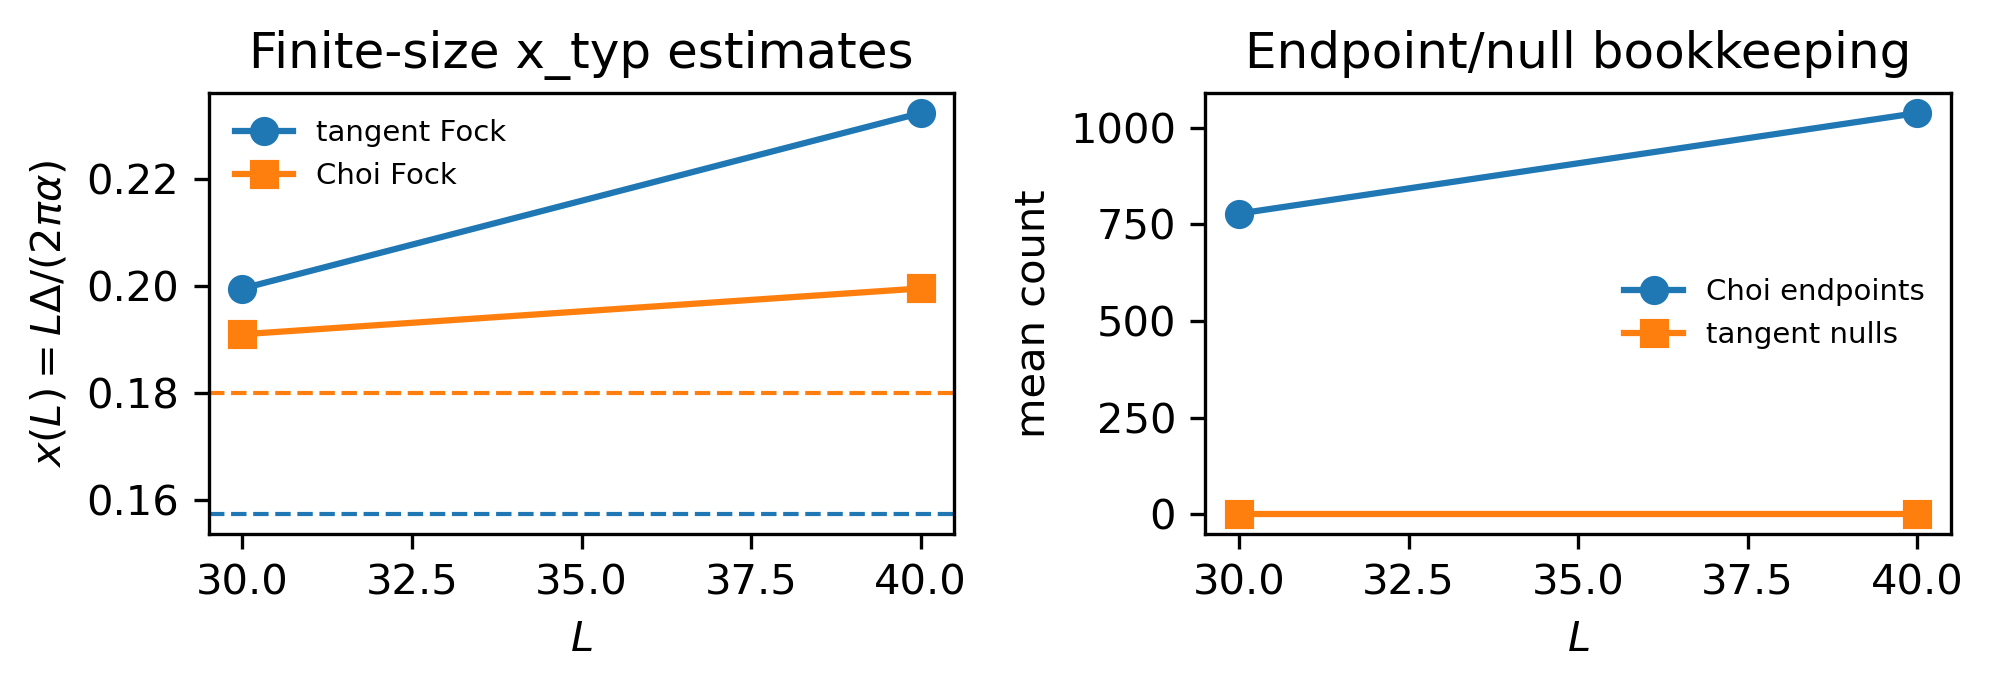

In [8]:

# Combined figure: size-resolved x estimates and endpoint/null bookkeeping.
x_tan = np.array([float(r['x_tangent_fock_size']) for r in scalars])
x_choi = np.array([float(r['x_choi_fock_size']) for r in scalars])
endpoint = np.array([float(r['choi_endpoint_mean']) for r in scalars])
nulls = np.array([float(r['tangent_null_mean']) for r in scalars])
fig, axes = plt.subplots(1, 2, figsize=(6.75, 2.4), dpi=300)
axes[0].plot(L, x_tan, 'o-', label='tangent Fock')
axes[0].plot(L, x_choi, 's-', label='Choi Fock')
if np.isfinite(float(fit.get('x_tangent_fock', np.nan))):
    axes[0].axhline(float(fit['x_tangent_fock']), color='tab:blue', ls='--', lw=1)
if np.isfinite(float(fit.get('x_choi_fock', np.nan))):
    axes[0].axhline(float(fit['x_choi_fock']), color='tab:orange', ls='--', lw=1)
axes[0].set_xlabel(r'$L$')
axes[0].set_ylabel(r'$x(L)=L\Delta/(2\pi\alpha)$')
axes[0].set_title('Finite-size x_typ estimates')
axes[0].legend(frameon=False, fontsize=7)
axes[1].plot(L, endpoint, 'o-', label='Choi endpoints')
axes[1].plot(L, nulls, 's-', label='tangent nulls')
axes[1].set_xlabel(r'$L$')
axes[1].set_ylabel('mean count')
axes[1].set_title('Endpoint/null bookkeeping')
axes[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(key_plot_dir / 'x_size_and_endpoint_counts.png')
plt.show()


## Endpoint and Null-Sector Bookkeeping

Gain/loss and projective limits can generate Choi endpoint sectors and tangent null/divergent directions. These sectors are excluded from finite-gap estimates but retained here because their multiplicity is physical bookkeeping data.


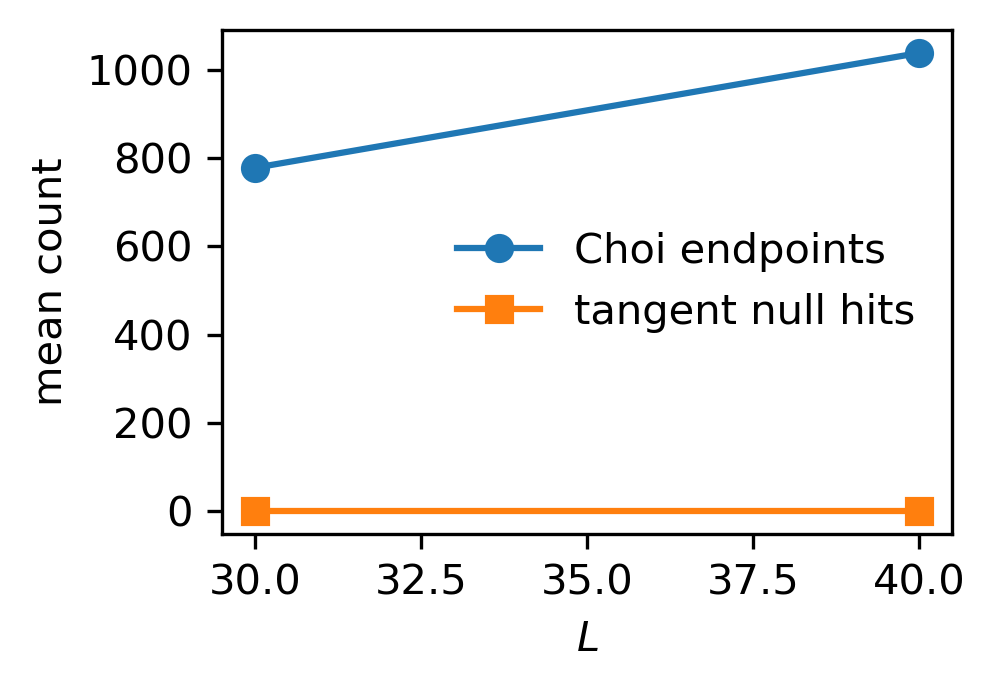

In [9]:
# Figure: endpoint and null-sector bookkeeping.
endpoint = np.array([float(r['choi_endpoint_mean']) for r in scalars])
nulls = np.array([float(r['tangent_null_mean']) for r in scalars])
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.plot(L, endpoint, 'o-', label='Choi endpoints')
ax.plot(L, nulls, 's-', label='tangent null hits')
ax.set_xlabel(r'$L$')
ax.set_ylabel('mean count')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(key_plot_dir / 'endpoint_null_bookkeeping.png')
plt.show()


## Raw Fit and Scalar Records

The final cell prints the exact fit dictionary and the scalar rows used by the figures. Use this section to sanity-check the numerical values against the saved CSV/JSON files.


In [10]:
# Summary table.
print(json.dumps(fit, indent=2))
for row in scalars:
    print(row)


{
  "ceff": -256.94483488852063,
  "ceff_fit": {
    "intercept": 3.191009438419033,
    "slope": 134.53600094393644,
    "intercept_se": NaN,
    "slope_se": NaN,
    "n": 2
  },
  "alpha": 1.0,
  "x_tangent_fock": 0.15732551809089615,
  "x_tangent_fock_fit": {
    "intercept": 0.0002949738070156125,
    "slope": 0.9885053837131348,
    "intercept_se": NaN,
    "slope_se": NaN,
    "n": 2
  },
  "x_choi_fock": 0.17998690925697994,
  "x_choi_fock_fit": {
    "intercept": 7.69764139675427e-05,
    "slope": 1.1308911037281217,
    "intercept_se": NaN,
    "slope_se": NaN,
    "n": 2
  }
}
{'Nx': '20', 'Ny': '30', 'L': '30', 'cycles': '150', 'samples': '10', 'alpha': '1.0', 'valid_weight_samples': '10', 'f0': '3.340493883912295', 'f0_se': '0.019725655284705153', 'fock_rank': '1', 'tangent_one_body_gap': '0.04179939366757287', 'tangent_one_body_gap_se': '0.003690520478224127', 'tangent_fock_gap': '0.04179939366757287', 'tangent_fock_gap_se': '0.0037584026043873866', 'x_tangent_fock_size': 